In [4]:
from google.colab import files
uploaded = files.upload()

Saving CW2.csv to CW2.csv


In [39]:
# Importing Libraries

import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, LSTM, GRU, Bidirectional, Conv1D, GlobalMaxPooling1D, Dropout, Flatten
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification

In [40]:
# Loading the Dataset

df = pd.read_csv("CW2.csv")
df.columns = df.columns.str.strip()
df = df[['Sentence', 'Resolved pattern']].dropna()

In [41]:
# Filter valid labels

valid_labels = ["ADDED COMPOUND", "FUSED HEAD", "IMPLICIT REFERENCE", "METONYMIC REFERENCE"]
df = df[df["Resolved pattern"].isin(valid_labels)]

In [42]:
# Encode labels
label_enc = LabelEncoder()
df['label'] = label_enc.fit_transform(df['Resolved pattern'])
num_classes = len(label_enc.classes_)
print("Classes:", label_enc.classes_)

Classes: ['ADDED COMPOUND' 'FUSED HEAD' 'IMPLICIT REFERENCE' 'METONYMIC REFERENCE']


In [43]:
# Train-test split
X = df['Sentence'].values
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [44]:
#  Preprocessing for CNN/DNN/LSTM/GRU/BiLSTM

# Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

X_train_clean = np.array([clean_text(s) for s in X_train])
X_test_clean = np.array([clean_text(s) for s in X_test])


In [45]:
# Tokenization
max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_clean)

X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)


In [46]:
# Function to Evaluate Model

def evaluate_model(model, X_test, y_test, is_transformer=False):
    if is_transformer:
        y_probs = model.predict(X_test).logits
        y_pred = np.argmax(y_probs, axis=1)
    else:
        y_pred = np.argmax(model.predict(X_test), axis=1)

    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=label_enc.classes_))

In [47]:
# CNN Model

cnn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn_model.fit(X_train_pad, y_train, validation_split=0.2, epochs=5, batch_size=32)
evaluate_model(cnn_model, X_test_pad, y_test)



Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.3200 - loss: 1.3589 - val_accuracy: 0.5000 - val_loss: 1.1534
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5351 - loss: 1.0860 - val_accuracy: 0.6234 - val_loss: 0.9417
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6844 - loss: 0.7856 - val_accuracy: 0.6234 - val_loss: 0.8598
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.8437 - loss: 0.4713 - val_accuracy: 0.6406 - val_loss: 0.8690
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9618 - loss: 0.2077 - val_accuracy: 0.6500 - val_loss: 0.9912
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Test Accuracy: 0.5844806007509387
                     precision    recall  f1-score   support

     ADDED COMPOUND       0.44      0.45      0.45       200
         FUSED HEAD       0.59      0.63      0.61       200
 IMPLICIT REFERENCE       0.53      0.56      0.55       199
METONYMIC REFERENCE       0.80      0.70      0.74       200


In [48]:
# DNN Model

dnn_model = Sequential([
    Embedding(max_words, 512, input_length=max_len),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

dnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
dnn_model.fit(X_train_pad, y_train, validation_split=0.2, epochs=5, batch_size=32)
evaluate_model(dnn_model, X_test_pad, y_test)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.2565 - loss: 1.4094 - val_accuracy: 0.4047 - val_loss: 1.2181
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.6154 - loss: 1.0017 - val_accuracy: 0.5125 - val_loss: 1.1107
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.9228 - loss: 0.2462 - val_accuracy: 0.5625 - val_loss: 1.4408
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9953 - loss: 0.0198 - val_accuracy: 0.5375 - val_loss: 1.7505
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.9994 - loss: 0.0039 - val_accuracy: 0.5844 - val_loss: 1.8597
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Test Accuracy: 0.5394242803504381
                     precision    recall  f1-score   support

     ADDED COMPOUND       0.43      0.36      0.40       200
         FUSED HEAD       0.53      0.60      0.56       200
 IMPLICIT REFERENCE       0.61      0.52      0.56       199
METONYMIC REFERENCE       0.58      0.68      0.62       200

In [49]:
# LSTM Model

lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.fit(X_train_pad, y_train, validation_split=0.2, epochs=5, batch_size=32)
evaluate_model(lstm_model, X_test_pad, y_test)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 173ms/step - accuracy: 0.2976 - loss: 1.3764 - val_accuracy: 0.4281 - val_loss: 1.2706
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.5204 - loss: 1.1551 - val_accuracy: 0.5234 - val_loss: 1.1077
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.6948 - loss: 0.8191 - val_accuracy: 0.5594 - val_loss: 1.0966
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.8685 - loss: 0.4237 - val_accuracy: 0.5359 - val_loss: 1.3007
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.9456 - loss: 0.1920 - val_accuracy: 0.5047 - val_loss: 1.6544
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Test Accuracy: 0.5043804755944932
                     precision    recall  f1-score   support

     ADDED COMPOUND       0.36      0.50      0.42       200
         FUSED HEAD       0.54      0.52      0.53       200
 IMPLICIT REFERENCE       0.56      0.45      0.50       199
METONYMIC REFERENCE       0.64      0.55      0.59       20

In [50]:
# GRU Model

gru_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    GRU(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_model.fit(X_train_pad, y_train, validation_split=0.3, epochs=2, batch_size=32)
evaluate_model(gru_model, X_test_pad, y_test)


Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.2650 - loss: 1.3821 - val_accuracy: 0.4588 - val_loss: 1.2985
Epoch 2/2
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.4924 - loss: 1.2223 - val_accuracy: 0.4974 - val_loss: 1.1306
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Test Accuracy: 0.490613266583229
                     precision    recall  f1-score   support

     ADDED COMPOUND       0.38      0.52      0.44       200
         FUSED HEAD       0.46      0.24      0.32       200
 IMPLICIT REFERENCE       0.51      0.56      0.53       199
METONYMIC REFERENCE       0.63      0.65      0.64       200

           accuracy                           0.49       799
          macro avg       0.49      0.49      0.48       799
       weighted avg       0.49      0.49      0.48       799



In [51]:
# BiLSTM Model

bilstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

bilstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
bilstm_model.fit(X_train_pad, y_train, validation_split=0.2, epochs=5, batch_size=32)
evaluate_model(bilstm_model, X_test_pad, y_test)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 158ms/step - accuracy: 0.2680 - loss: 1.3855 - val_accuracy: 0.3969 - val_loss: 1.2790
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 163ms/step - accuracy: 0.4530 - loss: 1.1992 - val_accuracy: 0.5375 - val_loss: 1.1454
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 146ms/step - accuracy: 0.6885 - loss: 0.8518 - val_accuracy: 0.5609 - val_loss: 1.0810
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.8658 - loss: 0.4480 - val_accuracy: 0.5344 - val_loss: 1.3205
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - accuracy: 0.9317 - loss: 0.2328 - val_accuracy: 0.5234 - val_loss: 1.5988
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step
Test Accuracy: 0.48685857321652065
                     precision    recall  f1-score   support

     ADDED COMPOUND       0.41      0.45      0.43       200
         FUSED HEAD       0.47      0.65      0.55       200
 IMPLICIT REFERENCE       0.49      0.44      0.46       199
METONYMIC REFERENCE       0.64      0.41      0.50

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

In [53]:
# Dictionary to store accuracies
model_accuracies = {}

# Helper function to evaluate and store accuracy
def evaluate_and_store(model, X_test, y_test, model_name):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    acc = accuracy_score(y_test, y_pred)
    model_accuracies[model_name] = acc
    print(f"=== {model_name} ===")
    print("Test Accuracy:", acc)
    print(classification_report(y_test, y_pred, target_names=label_enc.classes_))
    print("\n")

In [54]:
# Evaluate all models

evaluate_and_store(cnn_model, X_test_pad, y_test, 'CNN')
evaluate_and_store(dnn_model, X_test_pad, y_test, 'DNN')
evaluate_and_store(lstm_model, X_test_pad, y_test, 'LSTM')
evaluate_and_store(gru_model, X_test_pad, y_test, 'GRU')
evaluate_and_store(bilstm_model, X_test_pad, y_test, 'BiLSTM')


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
=== CNN ===
Test Accuracy: 0.5844806007509387
                     precision    recall  f1-score   support

     ADDED COMPOUND       0.44      0.45      0.45       200
         FUSED HEAD       0.59      0.63      0.61       200
 IMPLICIT REFERENCE       0.53      0.56      0.55       199
METONYMIC REFERENCE       0.80      0.70      0.74       200

           accuracy                           0.58       799
          macro avg       0.59      0.58      0.59       799
       weighted avg       0.59      0.58      0.59       799



25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
=== DNN ===
Test Accuracy: 0.5394242803504381
                     precision    recall  f1-score   support

     ADDED COMPOUND       0.43      0.36      0.40       200
         FUSED HEAD       0.53      0.60      0.56       200
 IMPLICIT REFERENCE       0.61      0.52      0.56       199
METONYMIC REFERENCE       0.58      0.68      0.62       200

           accuracy           

Text(0.5, 1.0, 'Comparison of Deep Learning Models')

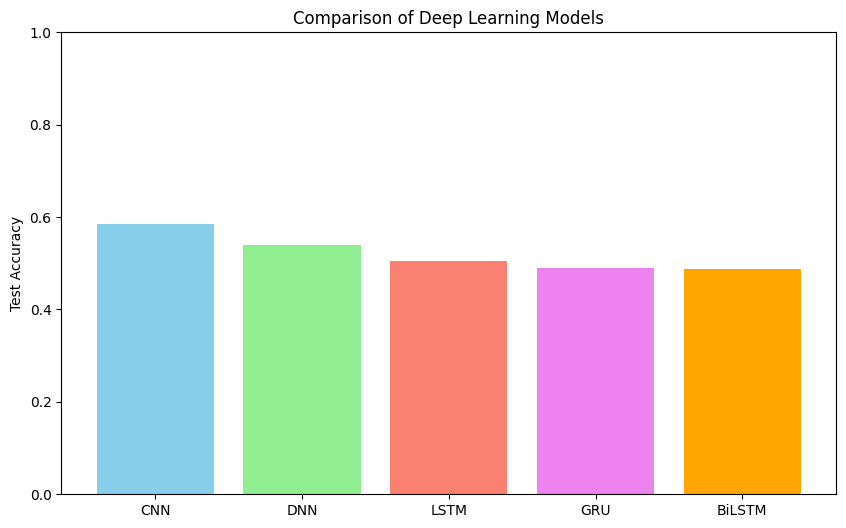

In [55]:
# Create Comparison Bar Chart

model_names = list(model_accuracies.keys())
accuracies = list(model_accuracies.values())

plt.figure(figsize=(10,6))
bars = plt.bar(model_names, accuracies, color=['skyblue', 'lightgreen', 'salmon', 'violet', 'orange'])
plt.ylim(0, 1)
plt.ylabel('Test Accuracy')
plt.title('Comparison of Deep Learning Models')

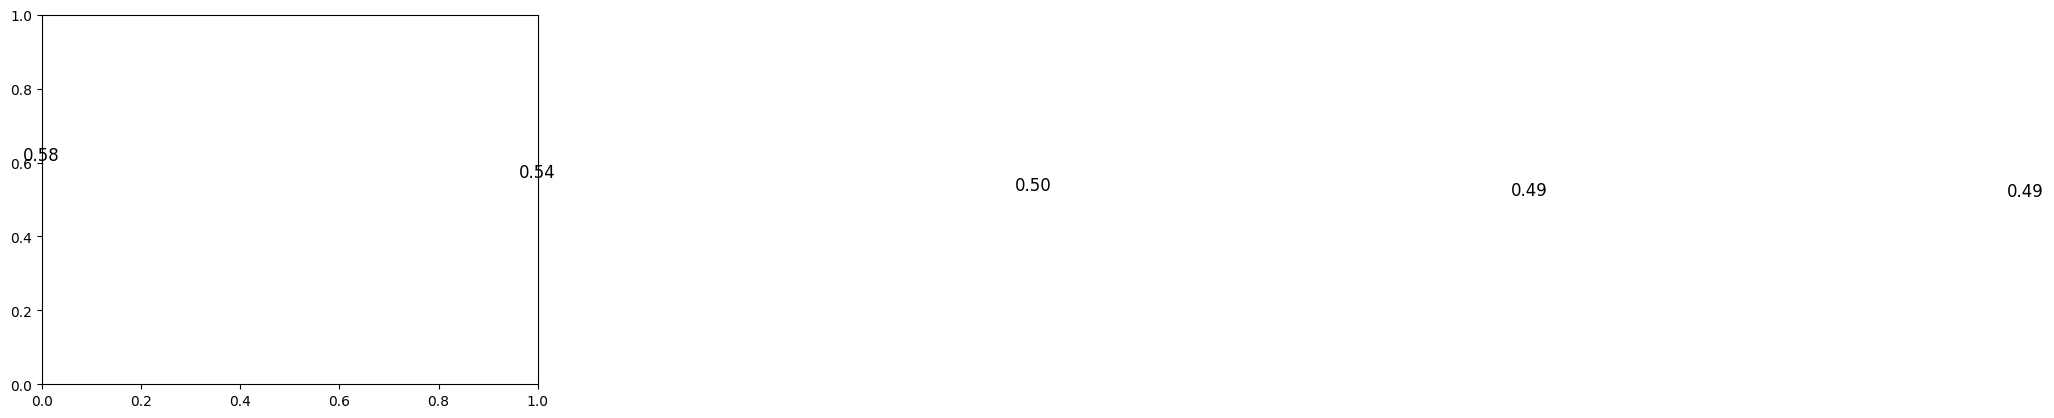

In [56]:
# Annotate accuracy on top of each bar
for bar, acc in zip(bars, accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{acc:.2f}', ha='center', va='bottom', fontsize=12)

plt.show()